In [72]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'Your API key goes here. Make sure to put your API key once again, down below in the 'def api_runner()' function.',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

In [73]:
type(data)

dict

In [74]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [75]:
#This normalises the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20021100.00000,20021100.00000,21000000.00000,2010-07-13T00:00:00.000Z,12615,1,2026-04-26T17:40:00.000Z,None,NaN,NaN,NaN,1561533965919.01001,"[mineable, pow, sha-256, store-of-value, state...",77994.41419,16677301514.13109,16643593857.04272,33707657.08836,-15.06020,-0.07807,0.84059,3.75785,18.41774,13.68135,-10.86902,1561533965919.00879,59.95540,1637882697968.60010,None,2026-04-26T17:40:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-26 18:40:56.871058
1,1027,Ethereum,ETH,ethereum,True,120688830.21742,120688830.21742,NaN,2015-08-07T00:00:00.000Z,11852,2,2026-04-26T17:39:00.000Z,None,NaN,NaN,NaN,283085315482.17999,"[pos, smart-contracts, ethereum-ecosystem, coi...",2345.58008,7557657198.14963,7486166079.26123,71491118.88839,-2.51180,-0.02952,1.48473,1.48079,18.27732,13.45239,-19.23251,283085315482.17798,10.86910,283085315482.17999,None,2026-04-26T17:39:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-26 18:40:56.871058
2,825,Tether USDt,USDT,tether,True,189794620624.49109,192219878140.31607,NaN,2015-02-25T00:00:00.000Z,179068,3,2026-04-26T17:38:00.000Z,None,NaN,NaN,NaN,192251389379.22000,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00016,86762358453.89917,85507496490.46974,1254861963.42943,-11.48330,0.00243,0.00383,0.00086,0.08418,-0.00171,0.10951,189825734282.92743,7.28840,192251389379.22000,None,2026-04-26T17:38:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-26 18:40:56.871058
3,52,XRP,XRP,xrp,False,61684942428.00000,99985673125.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1828,4,2026-04-26T17:39:00.000Z,None,NaN,NaN,NaN,142468984117.82999,"[medium-of-exchange, enterprise-solutions, xrp...",1.42489,1055248145.05727,1054847265.35774,400879.69953,-7.74190,-0.18956,0.25803,0.33339,7.12497,-2.91090,-25.29936,87894503366.47139,3.37470,142489398395.82999,None,2026-04-26T17:39:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-26 18:40:56.871058
4,1839,BNB,BNB,bnb,False,134786305.48000,134786305.48000,134786305.48000,2017-07-25T00:00:00.000Z,3195,5,2026-04-26T17:38:00.000Z,None,NaN,NaN,NaN,85127983386.94000,"[marketplace, centralized-exchange, payments, ...",631.57739,702065994.32522,672568351.19159,29497643.13363,-10.67220,-0.04499,0.55696,1.26441,3.72424,0.63194,-27.41874,85127983386.93730,3.26850,85127983386.94000,None,2026-04-26T17:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-26 18:40:56.871058
5,3408,USDC,USDC,usd-coin,False,77688896940.90433,77688896940.90433,NaN,2018-10-08T00:00:00.000Z,38977,6,2026-04-26T17:39:00.000Z,None,NaN,60901219650.23000,60891010614.41077,77675873741.42999,"[medium-of-exchange, stablecoin, asset-backed-...",0.99983,48803667084.81580,47836961358.08909,966705726.72676,-11.16000,-0.00246,0.00690,0.00966,-0.00637,-0.03175,-0.00528,77675873741.43179,2.98240,77675873741.42999,None,2026-04-26T17:39:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-26 18:40:56.871058
6,5426,Solana,SOL,solana,True,575850873.39568,625177027.96670,NaN,2020-04-10T00:00:00.000Z,1124,7,2026-04-26T17:38:00.000Z,None,NaN,525236893.30000,45407769797.91668,54047792398.02000,"[pos, platform, solana-ecosystem, cms-holdings...",86.45198,2672330426.54951,2672262158.72811,68267.82140,3.17220,-0.13161,0.89157,1.03863,4.43774,-2.23130,-30.00872

In [76]:

def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': 'Your API key goes here.',
    }
    
    session = Session()
    session.headers.update(headers)
    
    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

    
    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df

    if not os.path.isfile(r"C:\Users\Fyl\Downloads\Project2\API.csv"):
        df.to_csv(r"C:\Users\Fyl\Downloads\Project2\API.csv", header='column_names')
    else:
        df.to_csv(r'C:\Users\Fyl\Downloads\Project2\API.csv', mode='a', header=False)

In [99]:
import os
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print("API has successfully ran.")
    sleep(60) # Sleep for a minute, and will then run again.
exit()

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Fyl\\Downloads\\Project2\\API.csv'

In [ ]:
df72 = pd.read_csv(r"C:\Users\Fyl\Downloads\Project2\API.csv")
df72 

In [ ]:
# Change the scientific notation so it's easier to read.
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [ ]:
df

In [ ]:
# To observe trends overtime
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

In [83]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.07151
              quote.USD.percent_change_24h     0.79719
              quote.USD.percent_change_7d      3.16483
              quote.USD.percent_change_30d    18.55928
              quote.USD.percent_change_60d    14.77368
              quote.USD.percent_change_90d   -11.06605
Ethereum      quote.USD.percent_change_1h      0.05744
              quote.USD.percent_change_24h     1.62048
              quote.USD.percent_change_7d      1.04534
              quote.USD.percent_change_30d    18.40563
              quote.USD.percent_change_60d    15.21210
              quote.USD.percent_change_90d   -19.35649
Tether USDt   quote.USD.percent_change_1h      0.00639
              quote.USD.percent_change_24h     0.00749
              quote.USD.percent_change_7d     -0.00605
              quote.USD.percent_change_30d     0.07298
              quote.USD.percent_change_60d     0.00721
              quote.US

In [81]:
type(df4)

pandas.core.frame.DataFrame

In [85]:
df5 = df4.to_frame(name='values').reset_index()
df5

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.07151
1,Bitcoin,quote.USD.percent_change_24h,0.79719
2,Bitcoin,quote.USD.percent_change_7d,3.16483
3,Bitcoin,quote.USD.percent_change_30d,18.55928
4,Bitcoin,quote.USD.percent_change_60d,14.77368
5,Bitcoin,quote.USD.percent_change_90d,-11.06605
6,Ethereum,quote.USD.percent_change_1h,0.05744
7,Ethereum,quote.USD.percent_change_24h,1.62048
8,Ethereum,quote.USD.percent_change_7d,1.04534
9,Ethereum,quote.USD.percent_change_30d,18.40563


In [86]:
df5.rename(columns={'level_1': 'percent_change'}, inplace=True)

In [100]:
# Do not want to pass colums as indexes so I created an index to fix structure.
index = pd.Index(range(90))

df6 = df5.set_index(index)
df6

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.07151
1,Bitcoin,quote.USD.percent_change_24h,0.79719
2,Bitcoin,quote.USD.percent_change_7d,3.16483
3,Bitcoin,quote.USD.percent_change_30d,18.55928
4,Bitcoin,quote.USD.percent_change_60d,14.77368
5,Bitcoin,quote.USD.percent_change_90d,-11.06605
6,Ethereum,quote.USD.percent_change_1h,0.05744
7,Ethereum,quote.USD.percent_change_24h,1.62048
8,Ethereum,quote.USD.percent_change_7d,1.04534
9,Ethereum,quote.USD.percent_change_30d,18.40563


In [98]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.07151
1,Bitcoin,24h,0.79719
2,Bitcoin,7d,3.16483
3,Bitcoin,30d,18.55928
4,Bitcoin,60d,14.77368
5,Bitcoin,90d,-11.06605
6,Ethereum,quote.USD.percent_change_1h,0.05744
7,Ethereum,24h,1.62048
8,Ethereum,7d,1.04534
9,Ethereum,30d,18.40563


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

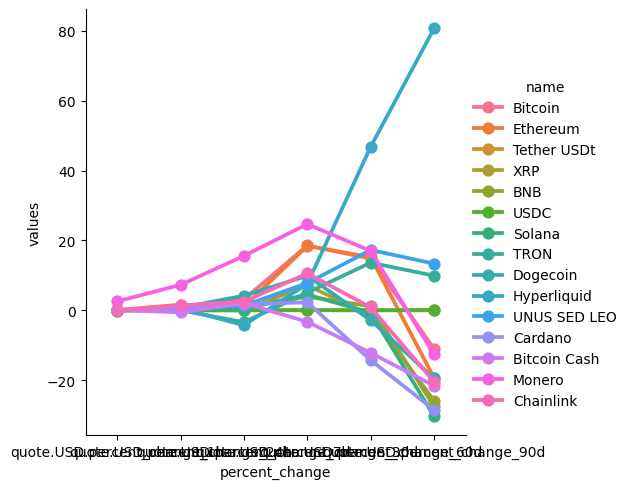

In [94]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')